In [38]:
from langchain_openai import ChatOpenAI

import os
from dotenv import load_dotenv

load_dotenv()
if os.environ.get("OPENAI_API_KEY"):
    print("Open AI API Key is set.")
else:
    raise ValueError("Open AI API Key is not set")

Open AI API Key is set.


In [39]:
from langchain.tools import tool
llm = ChatOpenAI(model = "gpt-5-mini")

In [40]:
# DuckDuckGo Search Tool
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

In [41]:
# Wikipedia Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.tools import tool

@tool
def wiki_tool(query: str):
    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)


In [42]:
@tool
def personal_info(name: str):

    """ Use this tool to get personal information about Alice, Bob, or Charlie. Provide the name as input to retrieve the information."""
    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

In [43]:
tools = [search_duckduckgo, wiki_tool, personal_info]
llm_with_tools = llm.bind_tools(tools)

# **LangGraph Creation**

In [44]:
from typing import TypedDict, List
from langchain_core.prompts import ChatPromptTemplate

class graph_schema(TypedDict):
    messages: List


# LLM Node
def llm_node(state:graph_schema) -> graph_schema:
    """This node takes a list of messages as input and returns the same list of messages as output."""
    messages = state["messages"]
    pt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that can use tools to answer questions."),
        ("human", "{input}")
    ])
    chain = pt | llm_with_tools
    response = chain.invoke({"input":messages})

    state["messages"].append(response)
    return state

In [45]:
# from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage, HumanMessage

def tool_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    tools_by_name = {tool.name: tool for tool in tools}
    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

In [46]:
# Create conditional edge function

def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

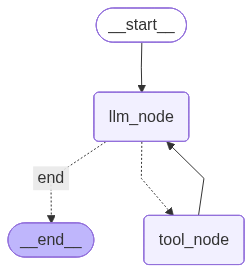

In [47]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")

# From llm node if tool call exists go to tool node else go to end  Mapping the dictionary keys to the node names in the graph
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

In [48]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 160, 'prompt_tokens': 244, 'total_tokens': 404, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNGAuASJgrARrvjIradouZRuXY143', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24a2-05ef-77a0-8ef1-37a68091cf94-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest AI news March 2026'}, 'id': 'call_gzscVkj17dCeD6h85mReO89P', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 244, 'output_tokens': 160, 'total

In [49]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="What is the latest news on AI?")]},
    stream_mode="updates"
):
    print(chunk)
    

{'llm_node': {'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 244, 'total_tokens': 337, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNGLbA4NiwLr3kXrh5do7HiSGbWRq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24ac-247a-75b3-85aa-76db7bc52c61-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': 'call_iaObHyLXcnrJPfziCeFf2vcX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 244, 'output_tokens': 93, 'total